# Solución Linda Vasquez

## 1. Instalar dependencias

In [ ]:
pip install pandas requests lxml beautifulsoup4

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Descarga y transformación del HTML

In [11]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io #para manejar textos como archivos

# Se descarga el contenido
url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"

# Para evitar un bloqueo por parte de Wikipedia se usa un request header para pasar como una busqueda de navegador normal
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36"
}

# Se pasa el header al método get
response = requests.get(url, headers=headers)

print("Estado:", response.status_code)

# Se verifica si la descarga fue exitosa
if response.status_code == 200:
    # Si el codigo respuesta es 200, se transforma el HTML en un objeto 'soup'
    soup = BeautifulSoup(response.text, 'html')

    # Tuve que envolver el texto HTML en io.StringIO para que Pandas lo lea sin buggearse
    html_data = io.StringIO(response.text)
    
    # Y se usa la función de Pandas para leer tablas. Selecciono la primera que contenga los datos
    tables = pd.read_html(html_data)
    df = tables[0] 
    print("Se ha cargado la tabla")

    print(df.head()) # para ver las primeras 5 filas
else:
    print(f"Error al acceder a la página: {response.status_code}")

Estado: 200
Se ha cargado la tabla
  Rank               Song                 Artist(s) Streams (billions)  \
0    1  "Blinding Lights"                The Weeknd              5.382   
1    2     "Shape of You"                Ed Sheeran              4.878   
2    3  "Sweater Weather"         The Neighbourhood              4.553   
3    4          "Starboy"  The Weeknd and Daft Punk              4.495   
4    5        "As It Was"              Harry Styles              4.375   

        Release date Ref.  
0   29 November 2019  [1]  
1     6 January 2017  [2]  
2    3 December 2012  [3]  
3  21 September 2016  [4]  
4       1 April 2022  [5]  


## 3. Procesar el DataFrame

In [5]:
# Eliminar filas que estén vacias
df_clean = df.dropna(how='all')

# Limpiar los nombres de las columnas, o sea nombres defectuosos
df_clean.columns = [col.replace('[', '').replace(']', '').strip() for col in df_clean.columns]

# Seleccionar solo las columnas que realmente interesan
columnas_importantes = ['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date']
df_final = df_clean[columnas_importantes].copy()

# Asegurar que los streams sean números para poder graficarlos después, se usa pd.to_numeric para que la columna sea numérica, y errors='coerce' convierte los errores en NaN
df_final['Streams (billions)'] = pd.to_numeric(df_final['Streams (billions)'], errors='coerce')

# Mostrar la tabla limpia
print("Datos limpios:")
print(df_final.head())

Datos limpios:
  Rank               Song                 Artist(s)  Streams (billions)  \
0    1  "Blinding Lights"                The Weeknd               5.382   
1    2     "Shape of You"                Ed Sheeran               4.878   
2    3  "Sweater Weather"         The Neighbourhood               4.553   
3    4          "Starboy"  The Weeknd and Daft Punk               4.495   
4    5        "As It Was"              Harry Styles               4.375   

        Release date  
0   29 November 2019  
1     6 January 2017  
2    3 December 2012  
3  21 September 2016  
4       1 April 2022  


## 4. Almacenar los datos en SQLite

In [6]:
# Crear la conexión
conn = sqlite3.connect('spotify_data.db')

# Guardar el DataFrame en la tabla SQL, if_exists='replace' para evitar que me diga que la tabla ya existe, sino que la reemplace
df_final.to_sql('top_songs', conn, if_exists='replace', index=False)

# Confirmar los cambios y cerrar la conexión
conn.commit()
conn.close()

print("Datos almacenados exitosamente en la base de datos 'spotify_data.db'")

Datos almacenados exitosamente en la base de datos 'spotify_data.db'


## 5. Visualización de los datos

/tmp/ipykernel_831/713362728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Streams (billions)', y='Song', palette='viridis')


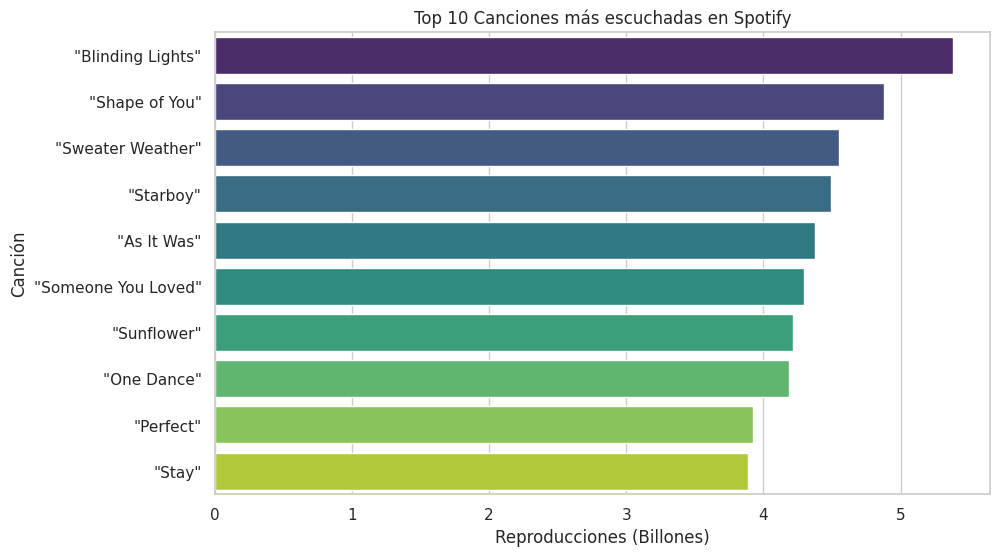

/tmp/ipykernel_831/713362728.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artistas_top.values, y=artistas_top.index, palette='coolwarm')


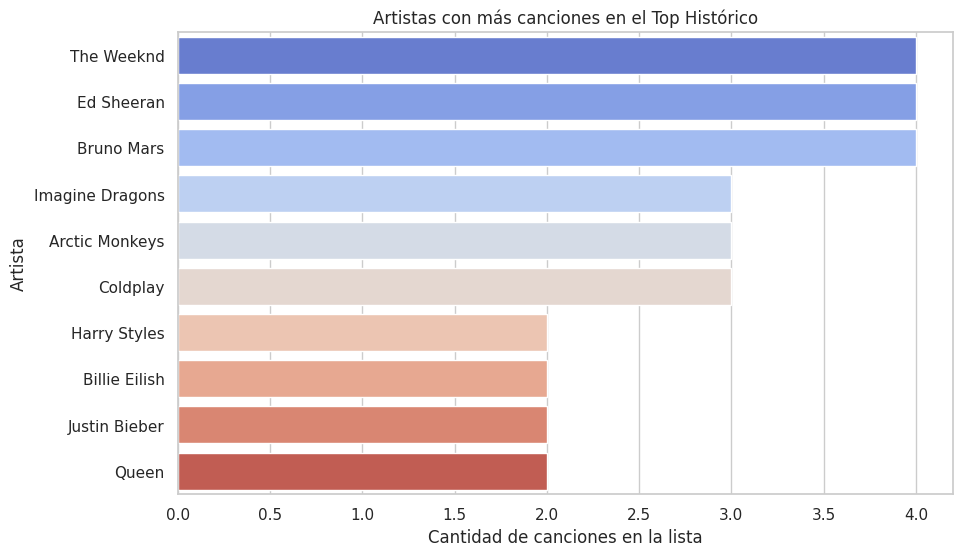

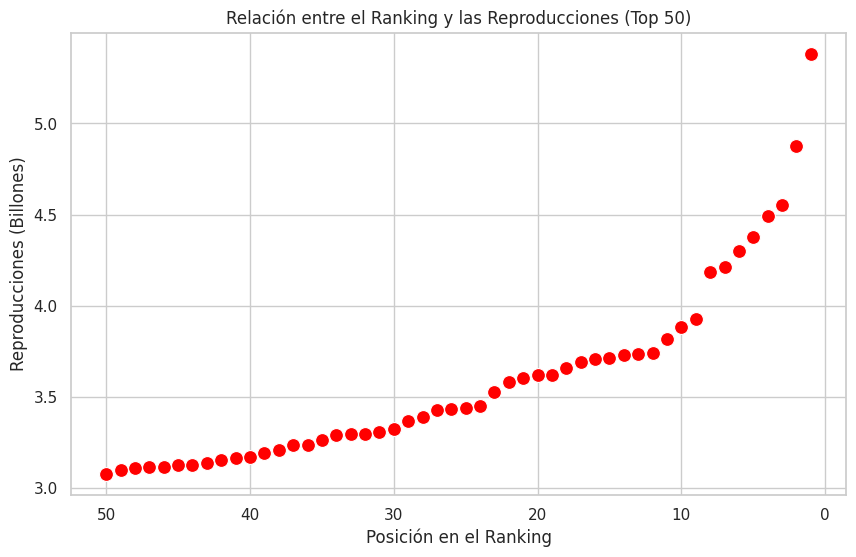

In [ ]:
sns.set_theme(style="whitegrid")

# Gráfica 1: Las 10 canciones más escuchadas
plt.figure(figsize=(10, 6))
top_10 = df_final.head(10)
sns.barplot(data=top_10, x='Streams (billions)', y='Song', palette='viridis')
plt.title('Top 10 Canciones más escuchadas en Spotify')
plt.xlabel('Reproducciones (Billones)')
plt.ylabel('Canción')
plt.show()

# Gráfica 2: Artistas con más canciones en todo el ranking
plt.figure(figsize=(10, 6))
# Contamos cuántas veces se repite cada artista y agarramos los 10 primeros
artistas_top = df_final['Artist(s)'].value_counts().nlargest(10)
sns.barplot(x=artistas_top.values, y=artistas_top.index, palette='coolwarm')
plt.title('Artistas con más canciones en el Top Histórico')
plt.xlabel('Cantidad de canciones en la lista')
plt.ylabel('Artista')
plt.show()

# Gráfica 3: Dispersión de Reproducciones por Ranking

# .to_numeric para convertir texto a numero, y me tocó usar errors='coerce' para ignorar cualquier letra extraña que haya en Wikipedia
df_final['Rank'] = pd.to_numeric(df_final['Rank'], errors='coerce')
df_final['Streams (billions)'] = pd.to_numeric(df_final['Streams (billions)'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final.head(50), x='Rank', y='Streams (billions)', color='red', s=100)
plt.title('Relación entre el Ranking y las Reproducciones (Top 50)')
plt.xlabel('Posición en el Ranking')
plt.ylabel('Reproducciones (Billones)')
# Invertimos el eje X para que el puesto #1 salga a la izquierda
plt.gca().invert_xaxis() 
plt.show()